# Jasmin Experiments

Notebook orchestration only. Shared implementation lives in `src/`.

ROADMAP: 
Baseline PatchCore          0.40  (done)
+ multi-view fusion         ~0.45 (1 hour)
+ DINOv2 backbone           ~0.55 (1 day)
+ supervised patch MLP      ~0.75-0.85 (2-3 days)
+ ensemble + TTA            ~0.80+ (polish)

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.common.config import load_config
from src.common.data import SpacepressoDataModule
from src.common.evaluation import evaluate_predictions
from src.common.paths import resolve_path
from src.common.seed import set_seed
from src.common.submission import SubmissionWriter, validate_submission
from src.common.training import ExperimentRunner
from src.common.validation import make_validation_split
from src.common.visualization import show_predictions
from src.methods import get_method_class

In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")
print("PyTorch:", torch.__version__)

CUDA available: True
Device: NVIDIA GeForce RTX 4060 Ti
PyTorch: 2.3.1


In [3]:
# patchcore
#config = load_config(ROOT / "configs/patchcore_lite/jasmin_test.yaml")
# student teacher
config = load_config(ROOT / "configs/student_teacher/jasmin_st.yaml")

set_seed(config.get("seed", 42))

local_data = ROOT / "data" / "spacepresso"
if local_data.exists():
    config["data"]["root"] = str(local_data)
config["data"]["load_images"] = False

# --- Toggles ---
NO_BACKGROUND          = True   # zero out outer black background in predictions (post-processing)
NO_BACKGROUND_TRAINING = True   # exclude background patches from memory bank during training
BG_DILATION            = 16     # pixels to keep around the object border
BG_THRESHOLD           = 0.20   # default threshold (pixels below this = background)
BG_THRESHOLD_PER_CLASS = {
    "class_01": 0.40,
    "class_08": 0.40,
}

def get_bg_threshold(class_name):
    return BG_THRESHOLD_PER_CLASS.get(class_name, BG_THRESHOLD)

if NO_BACKGROUND_TRAINING:
    config["method"]["no_background"]          = True
    config["method"]["bg_threshold"]           = BG_THRESHOLD
    config["method"]["bg_dilation"]            = BG_DILATION
    config["method"]["bg_threshold_per_class"] = BG_THRESHOLD_PER_CLASS

dm = SpacepressoDataModule(**config["data"])
train_good = dm.load_train_good()
train_anomalies = dm.load_train_anomalies()
test = dm.load_test()
print({"train_good": len(train_good), "train_anomalies": len(train_anomalies), "test": len(test)})
DEV_CLASSES = ["class_05"]  # set to None to use all 8 classes
if DEV_CLASSES:
    train_good      = [s for s in train_good      if s.class_name in DEV_CLASSES]
    train_anomalies = [s for s in train_anomalies if s.class_name in DEV_CLASSES]
    test            = [s for s in test            if s.class_name in DEV_CLASSES]
    print(f"Filtered to {DEV_CLASSES}: {len(train_good)} train, {len(train_anomalies)} anomalies, {len(test)} test")

{'train_good': 19005, 'train_anomalies': 235, 'test': 5910}
Filtered to ['class_05']: 2640 train, 30 anomalies, 225 test


## Background extraction

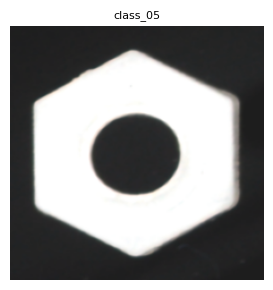

In [4]:
import matplotlib.pyplot as plt
from PIL import Image as PILImage
import numpy as np

classes = sorted({s.class_name for s in train_good})
fig, axes = plt.subplots(1, len(classes), figsize=(3 * len(classes), 3))
if len(classes) == 1:
    axes = [axes]
for ax, cls in zip(axes, classes):
    sample = next(s for s in train_good if s.class_name == cls)
    img = np.array(PILImage.open(sample.image_path).convert("RGB"))
    ax.imshow(img)
    ax.set_title(cls, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

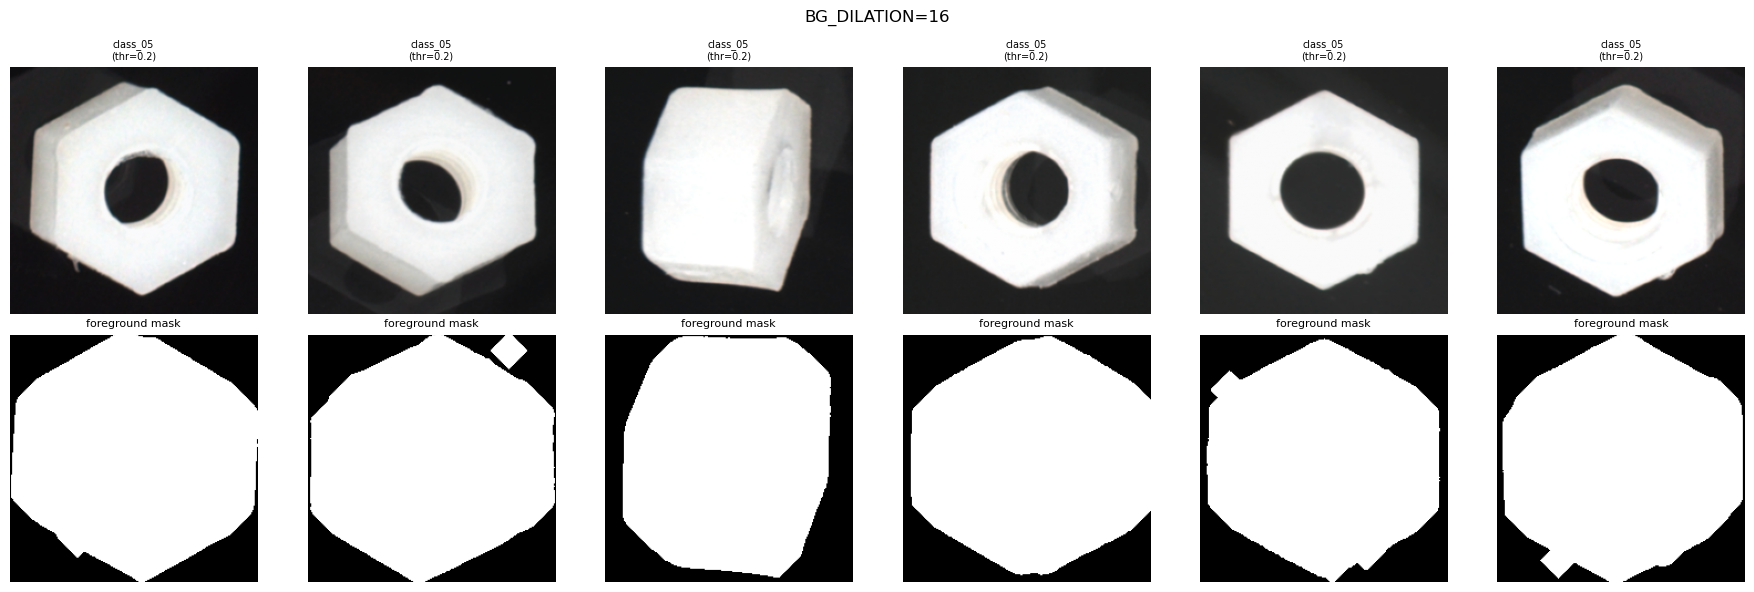

In [5]:
# Sanity check: visualize foreground masks on a few training images
if NO_BACKGROUND:
    import random
    import matplotlib.pyplot as plt
    from PIL import Image as PILImage
    import numpy as np
    from scipy.ndimage import binary_fill_holes, binary_dilation as _bdilate

    def _preview_foreground_mask(image_np, threshold, dilation):
        gray = image_np.mean(axis=2)
        fg = binary_fill_holes(gray > threshold)
        if dilation > 0:
            fg = _bdilate(fg, iterations=dilation)
        return fg.astype(np.float32)

    samples = random.sample(train_good, 6)
    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    for col, sample in enumerate(samples):
        img = np.array(PILImage.open(sample.image_path).convert("RGB").resize((config["data"]["image_size"], config["data"]["image_size"]))) / 255.0
        threshold = get_bg_threshold(sample.class_name)
        mask = _preview_foreground_mask(img, threshold, BG_DILATION)
        axes[0, col].imshow(img)
        axes[0, col].set_title(f"{sample.class_name}\n(thr={threshold})", fontsize=7)
        axes[0, col].axis("off")
        axes[1, col].imshow(mask, cmap="gray", vmin=0, vmax=1)
        axes[1, col].set_title("foreground mask", fontsize=8)
        axes[1, col].axis("off")
    plt.suptitle(f"BG_DILATION={BG_DILATION}")
    plt.tight_layout()
    plt.show()

## Training

In [6]:
if train_good and test:
    Method = get_method_class(config["method"]["name"])
    runner = ExperimentRunner(Method(config), config)
    runner.fit(train_good)
    predictions = runner.predict(test)
    show_predictions(test, predictions, n=3)
else:
    predictions = {}
    print("Dataset is empty or not found. Update config['data']['root'] before running.")


c:\Users\PC\anaconda3\envs\adl_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Training Student-Teacher for class_05: 2640 images
  patch_size=17 | stride=4 | 3 students x 4,832,384 params


[ST] p=17 epoch 01 | S0: 447.55525 | S1: 447.49195 | S2: 447.55469


[ST] p=17 epoch 02 | S0: 446.49661 | S1: 446.40311 | S2: 446.50257


[ST] p=17 epoch 03 | S0: 446.17970 | S1: 446.09428 | S2: 446.18448


KeyboardInterrupt: 

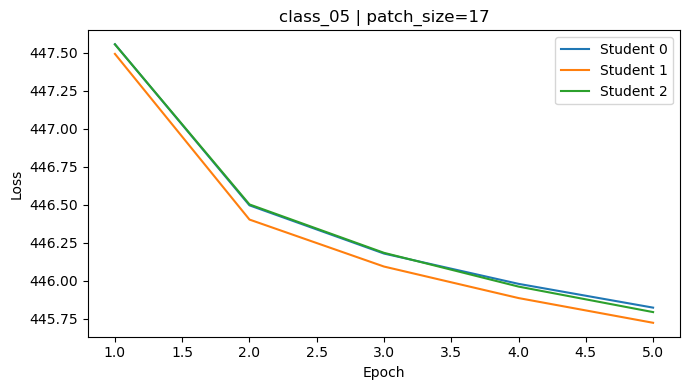

In [ ]:
runner.method.plot_training_history()

In [ ]:
# Background suppression: zero out outer black background in each prediction map
if NO_BACKGROUND and predictions:
    from PIL import Image as PILImage
    from scipy.ndimage import binary_fill_holes, binary_dilation as _bdilate
    import numpy as np

    image_size = config["data"]["image_size"]
    id_to_sample = {s.image_id: s for s in test}

    for img_id, pred in predictions.items():
        sample = id_to_sample[img_id]
        threshold = get_bg_threshold(sample.class_name)
        img = np.array(PILImage.open(sample.image_path).convert("RGB").resize((image_size, image_size))) / 255.0
        fg = binary_fill_holes(img.mean(axis=2) > threshold)
        if BG_DILATION > 0:
            fg = _bdilate(fg, iterations=BG_DILATION)
        predictions[img_id] = pred * fg.astype(np.float32)

    print("Background suppression applied.")

Background suppression applied.


In [ ]:
# Multi-view fusion: propagate the max anomaly score across all 5 views of the same product
# If any view detects a defect strongly, all views of that product get boosted accordingly.
MULTI_VIEW_FUSION = True

if MULTI_VIEW_FUSION and predictions:
    import numpy as np
    from collections import defaultdict

    # Map image_id → sample_id and sample_id → list of image_ids
    id_to_sample_id = {s.image_id: s.sample_id for s in test}
    sample_to_views = defaultdict(list)
    for s in test:
        sample_to_views[s.sample_id].append(s.image_id)

    # For each product sample, scale all views so their max equals the sample-level max
    n_boosted = 0
    for sample_id, image_ids in sample_to_views.items():
        maps = [predictions[iid] for iid in image_ids if iid in predictions]
        if not maps:
            continue
        sample_max = max(float(m.max()) for m in maps)
        for iid in image_ids:
            if iid not in predictions:
                continue
            m = predictions[iid]
            view_max = float(m.max())
            if view_max < sample_max - 1e-6:  # this view scored lower than the best view
                predictions[iid] = np.clip(m * (sample_max / max(view_max, 1e-6)), 0.0, 1.0).astype(m.dtype)
                n_boosted += 1

    print(f"Multi-view fusion applied: {n_boosted} views boosted out of {len(predictions)} total")

## Validation + File saving

In [ ]:
# Validation: evaluate on all anomalies + a sample of good images
if predictions:
    import random as _random
    import matplotlib.pyplot as plt
    from PIL import Image as PILImage
    import numpy as np
    from src.common.evaluation import load_sample_mask

    N_GOOD_VAL = 200
    good_sample = _random.sample(train_good, min(N_GOOD_VAL, len(train_good)))
    val_samples = train_anomalies + good_sample
    val_predictions = runner.predict(val_samples)

    if NO_BACKGROUND:
        from scipy.ndimage import binary_fill_holes, binary_dilation as _bdilate
        id_to_sample = {s.image_id: s for s in val_samples}
        image_size = config["data"]["image_size"]
        for img_id, pred in val_predictions.items():
            s = id_to_sample[img_id]
            threshold = get_bg_threshold(s.class_name)
            img = np.array(PILImage.open(s.image_path).convert("RGB").resize((image_size, image_size))) / 255.0
            fg = binary_fill_holes(img.mean(axis=2) > threshold)
            if BG_DILATION > 0:
                fg = _bdilate(fg, iterations=BG_DILATION)
            val_predictions[img_id] = pred * fg.astype(np.float32)

    metrics = evaluate_predictions(val_samples, val_predictions).as_dict()
    print(f"Evaluated on {len(train_anomalies)} anomalies + {len(good_sample)} good images")
    print(f"Pixel AP:    {metrics['pixel_ap']:.4f}")
    print(f"Image AP:    {metrics['image_ap']:.4f}")
    print(f"Pixel AUROC: {metrics['pixel_auroc']:.4f}")

    # Visualize 2 anomalous samples per class
    image_size = config["data"]["image_size"]
    grouped = {}
    for s in train_anomalies:
        grouped.setdefault(s.class_name, []).append(s)

    n_classes = len(grouped)
    fig, axes = plt.subplots(n_classes, 6, figsize=(18, 3 * n_classes), squeeze=False)
    for row, (cls, samples) in enumerate(sorted(grouped.items())):
        picks = _random.sample(samples, min(2, len(samples)))
        for col_offset, s in enumerate(picks):
            img  = np.array(PILImage.open(s.image_path).convert("RGB").resize((image_size, image_size)))
            gt   = load_sample_mask(s, (image_size, image_size))
            pred = val_predictions[s.image_id]
            c = col_offset * 3
            axes[row, c].imshow(img)
            axes[row, c].set_title(f"{cls}" if col_offset == 0 else "", fontsize=7)
            axes[row, c].axis("off")
            axes[row, c+1].imshow(gt,   cmap="hot", vmin=0, vmax=1)
            axes[row, c+1].set_title("ground truth" if row == 0 else "", fontsize=7)
            axes[row, c+1].axis("off")
            axes[row, c+2].imshow(pred, cmap="hot", vmin=0, vmax=1)
            axes[row, c+2].set_title("prediction" if row == 0 else "", fontsize=7)
            axes[row, c+2].axis("off")

    plt.suptitle("Anomaly validation — 2 samples per class (image | ground truth | prediction)", fontsize=9)
    plt.tight_layout()
    plt.show()

In [ ]:
SAVE_FILE = False

In [ ]:
if predictions and SAVE_FILE:
    import zipfile, random
    from datetime import datetime
    from src.common.submission import _prepare_prediction_map
    from src.common.q8rle import float_matrix_to_q8rle, q8rle_to_float_matrix

    expected_shape = (config["data"]["image_size"], config["data"]["image_size"])
    sorted_ids = sorted(predictions)
    assert len(sorted_ids) == len(test), f"Expected {len(test)} predictions, got {len(sorted_ids)}"

    sample_indices = set(random.sample(range(len(sorted_ids)), min(5, len(sorted_ids))))
    sampled_labels = {}

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    base_path = resolve_path(config["submission"]["output_path"], ROOT)
    zip_path = base_path.parent / f"{base_path.stem}_{timestamp}.zip"
    zip_path.parent.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
        with zf.open(base_path.stem + ".csv", "w") as f:
            f.write(b"ID,Label\n")
            for i, img_id in enumerate(sorted_ids):
                label = float_matrix_to_q8rle(_prepare_prediction_map(predictions[img_id]))
                f.write(f"{img_id},{label}\n".encode("utf-8"))
                if i in sample_indices:
                    sampled_labels[img_id] = label

    for img_id, label in sampled_labels.items():
        assert label.startswith("q8rle"), f"Bad label for {img_id}"
        assert q8rle_to_float_matrix(label).shape == expected_shape, f"Shape mismatch for {img_id}"

    print(f"Validated: {len(sorted_ids)} rows, spot-checked {len(sampled_labels)}, shape {expected_shape}")
    print(f"Saved: {zip_path} ({zip_path.stat().st_size / 1024**2:.1f} MB)")